# WDR91 — GNN via Pseudo-Labeling on Step 2 SMILES

**Goal:** Train a Graph Neural Network (GNN) on Step 2 SMILES using pseudo-labels generated by the pretrained XGBoost model.

**Why this helps:** XGBoost was trained on DEL fingerprints — a fixed representation. The GNN learns directly from molecular graphs in the drug-like Step 2 chemical space, overcoming the domain shift between DEL and commercial compounds.

**Pseudo-labeling strategy:**
- Top 5% by XGBoost score → pseudo-positive (likely hits)
- Bottom 60% by XGBoost score → pseudo-negative (likely non-hits)
- Middle 35% discarded (uncertain zone)

**GNN architecture:** 3-layer Graph Convolutional Network (GCN) with global mean pooling.

---
**Before running, upload to Google Drive:**
- `Step2_TestData_Target2035.parquet` → `My Drive/CS502/data/Step2_TestData_Target2035.parquet`
- `xgb_multifp.json` → `My Drive/CS502/models/xgb_multifp.json` (from notebook 04)

In [1]:
!pip install torch-geometric rdkit pyarrow xgboost tqdm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 69.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

STEP2_PATH  = '/content/drive/MyDrive/CS502/data/Step2_TestData_Target2035.parquet'
MODEL_PATH  = '/content/drive/MyDrive/CS502/models/xgb_multifp.json'
OUTPUT_PATH = '/content/drive/MyDrive/CS502/outputs/predictions_gnn.csv'
GNN_PATH    = '/content/drive/MyDrive/CS502/models/gnn_pseudolabel.pt'

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
import xgboost as xgb
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from rdkit import Chem
from rdkit.Chem import AllChem
from pathlib import Path
from tqdm import tqdm

%matplotlib inline
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
Path('/content/drive/MyDrive/CS502/models').mkdir(parents=True, exist_ok=True)
Path('/content/drive/MyDrive/CS502/outputs').mkdir(parents=True, exist_ok=True)

Using device: cuda


## Helper Functions

In [4]:
# ── Fingerprint parsing (Step 2 dense string format) ─────────────────────────
FP_DIMS  = {'ECFP6': 2048, 'MACCS': 167, 'RDK': 2048}
FP_NAMES = ['ECFP6', 'MACCS', 'RDK']

def dense_string_to_matrix(dense_strings, n_bits):
    rows, cols = [], []
    for i, s in enumerate(dense_strings):
        on_bits = np.where(np.array(s.split(','), dtype=np.int32) > 0)[0]
        rows.extend([i] * len(on_bits))
        cols.extend(on_bits.tolist())
    return sp.csr_matrix(
        (np.ones(len(rows), dtype=np.float32), (rows, cols)),
        shape=(len(dense_strings), n_bits)
    )


def load_step2(path, fp_names=FP_NAMES, batch_size=20_000):
    pf = pq.ParquetFile(path)
    ids, smiles_list, fp_batches = [], [], {fp: [] for fp in fp_names}
    for batch in tqdm(pf.iter_batches(batch_size=batch_size,
                      columns=['RandomID', 'SMILES'] + fp_names), desc='Loading Step 2'):
        df = batch.to_pandas()
        ids.append(df['RandomID'])
        smiles_list.append(df['SMILES'])
        for fp in fp_names:
            fp_batches[fp].append(dense_string_to_matrix(df[fp].tolist(), FP_DIMS[fp]))
    X = sp.hstack([sp.vstack(fp_batches[fp], format='csr') for fp in fp_names], format='csr')
    return X, pd.concat(ids, ignore_index=True), pd.concat(smiles_list, ignore_index=True)


# ── Molecular graph featurization ─────────────────────────────────────────────
ATOM_TYPES = ['C','N','O','S','F','Si','P','Cl','Br','I','B','Se','Te','other']
HYBRIDIZATION = [
    Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3,
    Chem.rdchem.HybridizationType.SP3D,
    Chem.rdchem.HybridizationType.SP3D2,
]
BOND_TYPES = [
    Chem.rdchem.BondType.SINGLE,
    Chem.rdchem.BondType.DOUBLE,
    Chem.rdchem.BondType.TRIPLE,
    Chem.rdchem.BondType.AROMATIC,
]

def one_hot(val, choices):
    return [1 if val == c else 0 for c in choices]

def atom_features(atom):
    symbol = atom.GetSymbol() if atom.GetSymbol() in ATOM_TYPES[:-1] else 'other'
    return (
        one_hot(symbol, ATOM_TYPES) +                          # 14
        one_hot(atom.GetDegree(), list(range(8))) +            # 8
        one_hot(atom.GetTotalNumHs(), list(range(5))) +        # 5
        one_hot(atom.GetHybridization(), HYBRIDIZATION) +      # 5
        [atom.GetFormalCharge() / 4.0] +                       # 1
        [float(atom.IsInRing())] +                             # 1
        [float(atom.GetIsAromatic())]                          # 1
    )  # total: 35

def bond_features(bond):
    return (
        one_hot(bond.GetBondType(), BOND_TYPES) +              # 4
        [float(bond.GetIsConjugated())] +                      # 1
        [float(bond.IsInRing())]                               # 1
    )  # total: 6

def smiles_to_graph(smiles, label=None):
    """Convert SMILES string to PyG Data object. Returns None if invalid."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float)

    if mol.GetNumBonds() == 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr  = torch.zeros((0, 6), dtype=torch.float)
    else:
        rows, cols, attrs = [], [], []
        for bond in mol.GetBonds():
            i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            bf = bond_features(bond)
            rows += [i, j]; cols += [j, i]
            attrs += [bf, bf]  # undirected: add both directions
        edge_index = torch.tensor([rows, cols], dtype=torch.long)
        edge_attr  = torch.tensor(attrs, dtype=torch.float)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    if label is not None:
        data.y = torch.tensor([label], dtype=torch.float)
    return data

## 1. Load Step 2 Data & XGBoost Model

In [5]:
X_step2, compound_ids, smiles_series = load_step2(STEP2_PATH)
print(f'Step 2: {X_step2.shape[0]:,} compounds, {X_step2.shape[1]} features')

xgb_model = xgb.XGBClassifier()
xgb_model.load_model(MODEL_PATH)
print(f'XGBoost model loaded.')

Loading Step 2: 17it [04:17, 15.15s/it]


Step 2: 339,258 compounds, 4263 features
XGBoost model loaded.


## 2. Generate Pseudo-Labels

- **Top 5%** by XGBoost score → pseudo-positive (label = 1)
- **Bottom 60%** by XGBoost score → pseudo-negative (label = 0)
- **Middle 35%** discarded — too uncertain to label

In [6]:
POS_THRESHOLD = 0.05  # top 5%  → pseudo-positive
NEG_THRESHOLD = 0.60  # bottom 60% → pseudo-negative

print('Running XGBoost predictions on Step 2...')
xgb_scores = xgb_model.predict_proba(X_step2.astype(np.float32))[:, 1]

n = len(xgb_scores)
sorted_idx = np.argsort(xgb_scores)

n_pos = int(n * POS_THRESHOLD)
n_neg = int(n * NEG_THRESHOLD)

pos_idx = sorted_idx[-n_pos:]   # highest scores
neg_idx = sorted_idx[:n_neg]    # lowest scores

all_idx    = np.concatenate([pos_idx, neg_idx])
all_labels = np.array([1]*n_pos + [0]*n_neg)

print(f'Pseudo-positives : {n_pos:,}  (score ≥ {xgb_scores[pos_idx[0]]:.4f})')
print(f'Pseudo-negatives : {n_neg:,}  (score ≤ {xgb_scores[neg_idx[-1]]:.4f})')
print(f'Discarded (uncertain): {n - n_pos - n_neg:,}')
print(f'Pseudo-label imbalance: {n_neg/n_pos:.1f}:1')

Running XGBoost predictions on Step 2...
Pseudo-positives : 16,962  (score ≥ 0.0291)
Pseudo-negatives : 203,554  (score ≤ 0.0158)
Discarded (uncertain): 118,742
Pseudo-label imbalance: 12.0:1


## 3. Build PyG Dataset from Pseudo-Labeled SMILES

In [7]:
print('Converting SMILES to molecular graphs...')
dataset = []
failed  = 0

for i, (idx, label) in enumerate(tqdm(zip(all_idx, all_labels), total=len(all_idx))):
    smi  = smiles_series.iloc[idx]
    data = smiles_to_graph(smi, label=float(label))
    if data is not None:
        dataset.append(data)
    else:
        failed += 1

pos_count = sum(1 for d in dataset if d.y.item() == 1)
neg_count = len(dataset) - pos_count
print(f'\nDataset: {len(dataset):,} graphs  ({pos_count:,} pos, {neg_count:,} neg)')
print(f'Failed SMILES: {failed}')
print(f'Node feature dim: {dataset[0].x.shape[1]}')

Converting SMILES to molecular graphs...


100%|██████████| 220516/220516 [03:47<00:00, 967.25it/s] 



Dataset: 220,516 graphs  (16,962 pos, 203,554 neg)
Failed SMILES: 0
Node feature dim: 35


## 4. GNN Model Definition

3-layer Graph Convolutional Network with global mean pooling.

In [8]:
class MolGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels=256, num_layers=3, dropout=0.3):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        self.convs.append(GCNConv(in_channels, hidden_channels))
        self.bns.append(nn.BatchNorm1d(hidden_channels))
        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.bns.append(nn.BatchNorm1d(hidden_channels))

        self.dropout = dropout
        self.fc1 = nn.Linear(hidden_channels, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x, edge_index, batch):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = global_mean_pool(x, batch)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x.squeeze(-1)


IN_CHANNELS = dataset[0].x.shape[1]  # 35
model_gnn = MolGCN(in_channels=IN_CHANNELS, hidden_channels=256, num_layers=3).to(DEVICE)
print(model_gnn)
n_params = sum(p.numel() for p in model_gnn.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

MolGCN(
  (convs): ModuleList(
    (0): GCNConv(35, 256)
    (1-2): 2 x GCNConv(256, 256)
  )
  (bns): ModuleList(
    (0-2): 3 x BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)
Trainable parameters: 158,849


## 5. Train GNN

Train: 198,465  Val: 22,051
pos_weight: 12.00



/tmp/ipykernel_2308/3662354700.py:12: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
/tmp/ipykernel_2308/3662354700.py:13: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)


Epoch   5/30  train_loss=0.6478  val_loss=0.6276
Epoch  10/30  train_loss=0.5707  val_loss=0.5293
Epoch  15/30  train_loss=0.5028  val_loss=0.4793
Epoch  20/30  train_loss=0.4762  val_loss=0.4414
Epoch  25/30  train_loss=0.4332  val_loss=0.4168
Epoch  30/30  train_loss=0.4225  val_loss=0.3876


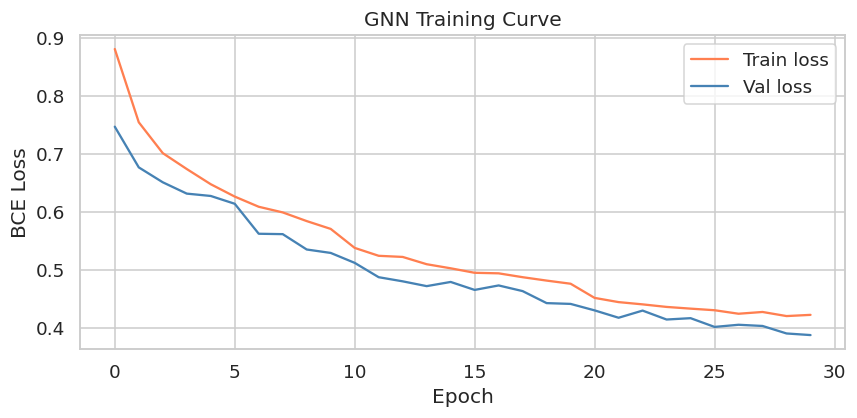


Model saved to /content/drive/MyDrive/CS502/models/gnn_pseudolabel.pt


In [9]:
BATCH_SIZE = 256
N_EPOCHS   = 30
LR         = 1e-3

# Shuffle and split 90/10 for train/val
np.random.seed(42)
perm = np.random.permutation(len(dataset))
val_size  = int(len(dataset) * 0.1)
val_data  = [dataset[i] for i in perm[:val_size]]
train_data = [dataset[i] for i in perm[val_size:]]

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)

# Class-weighted loss for imbalance
pos_weight = torch.tensor([neg_count / pos_count], dtype=torch.float).to(DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = torch.optim.Adam(model_gnn.parameters(), lr=LR, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

print(f'Train: {len(train_data):,}  Val: {len(val_data):,}')
print(f'pos_weight: {pos_weight.item():.2f}\n')

train_losses, val_losses = [], []

for epoch in range(N_EPOCHS):
    # Train
    model_gnn.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        out  = model_gnn(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    train_loss = total_loss / len(train_data)

    # Validate
    model_gnn.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(DEVICE)
            out  = model_gnn(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y)
            total_val_loss += loss.item() * batch.num_graphs
    val_loss = total_val_loss / len(val_data)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step()

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:3d}/{N_EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}')

# Plot training curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train loss', color='coral')
ax.plot(val_losses,   label='Val loss',   color='steelblue')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.set_title('GNN Training Curve')
ax.legend(); plt.tight_layout(); plt.show()

torch.save(model_gnn.state_dict(), GNN_PATH)
print(f'\nModel saved to {GNN_PATH}')

## 6. Predict on All Step 2 Compounds

In [10]:
print('Converting all Step 2 SMILES to graphs...')
all_graphs = []
valid_idx  = []

for i, smi in enumerate(tqdm(smiles_series)):
    g = smiles_to_graph(smi)
    if g is not None:
        all_graphs.append(g)
        valid_idx.append(i)

print(f'Valid graphs: {len(all_graphs):,} / {len(smiles_series):,}')

predict_loader = DataLoader(all_graphs, batch_size=512, shuffle=False)
gnn_scores_valid = []

model_gnn.eval()
with torch.no_grad():
    for batch in tqdm(predict_loader, desc='Predicting'):
        batch = batch.to(DEVICE)
        logits = model_gnn(batch.x, batch.edge_index, batch.batch)
        probs  = torch.sigmoid(logits).cpu().numpy()
        gnn_scores_valid.extend(probs.tolist())

# Map back to full index (fill 0 for failed SMILES)
gnn_scores = np.zeros(len(smiles_series))
for i, idx in enumerate(valid_idx):
    gnn_scores[idx] = gnn_scores_valid[i]

print(f'\nGNN scores: min={gnn_scores.min():.4f}  max={gnn_scores.max():.4f}  mean={gnn_scores.mean():.4f}')

Converting all Step 2 SMILES to graphs...


100%|██████████| 339258/339258 [05:44<00:00, 984.79it/s]
/tmp/ipykernel_2308/1931470171.py:13: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  predict_loader = DataLoader(all_graphs, batch_size=512, shuffle=False)


Valid graphs: 339,258 / 339,258


Predicting: 100%|██████████| 663/663 [00:14<00:00, 45.59it/s]



GNN scores: min=0.0000  max=1.0000  mean=0.3163


## 7. Results & Score Distribution

Correlation (XGBoost vs GNN): 0.6465


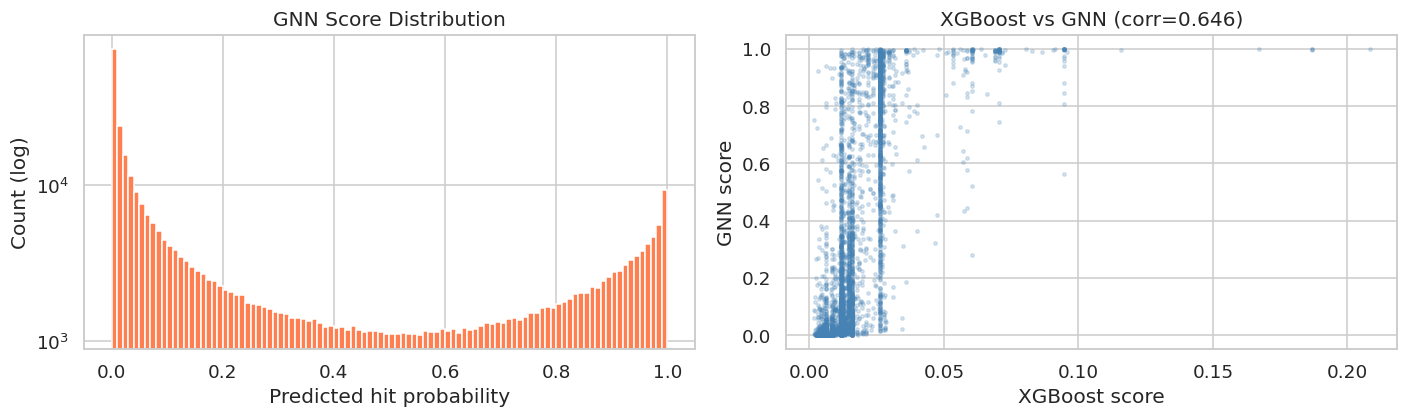


Top 10 by GNN score:
 rank  RandomID  xgb_score  gnn_score
    1  ID_21318   0.094459   1.000000
    2 ID_190824   0.094459   0.999999
    3 ID_195786   0.150574   0.999999
    4 ID_276163   0.094459   0.999999
    5 ID_171919   0.094459   0.999999
    6 ID_292582   0.094459   0.999999
    7  ID_59312   0.079697   0.999999
    8 ID_303098   0.094459   0.999999
    9  ID_57241   0.094459   0.999999
   10  ID_13624   0.208255   0.999999


In [11]:
results = pd.DataFrame({
    'RandomID':   compound_ids,
    'SMILES':     smiles_series,
    'xgb_score':  xgb_scores,
    'gnn_score':  gnn_scores,
})
results = results.sort_values('gnn_score', ascending=False).reset_index(drop=True)
results['rank'] = results.index + 1

corr = np.corrcoef(xgb_scores, gnn_scores)[0, 1]
print(f'Correlation (XGBoost vs GNN): {corr:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(gnn_scores, bins=100, color='coral', log=True)
axes[0].set_title('GNN Score Distribution')
axes[0].set_xlabel('Predicted hit probability')
axes[0].set_ylabel('Count (log)')

axes[1].scatter(xgb_scores[:5000], gnn_scores[:5000], alpha=0.2, s=5, color='steelblue')
axes[1].set_xlabel('XGBoost score')
axes[1].set_ylabel('GNN score')
axes[1].set_title(f'XGBoost vs GNN (corr={corr:.3f})')

plt.tight_layout(); plt.show()

print(f'\nTop 10 by GNN score:')
print(results[['rank','RandomID','xgb_score','gnn_score']].head(10).to_string(index=False))

## 8. Save Ranked Predictions

In [12]:
results.to_csv(OUTPUT_PATH, index=False)
print(f'Saved {len(results):,} ranked predictions to {OUTPUT_PATH}')
print('Columns: RandomID, SMILES, xgb_score, gnn_score, rank')
results.head()

Saved 339,258 ranked predictions to /content/drive/MyDrive/CS502/outputs/predictions_gnn.csv
Columns: RandomID, SMILES, xgb_score, gnn_score, rank


,RandomID,SMILES,xgb_score,gnn_score,rank
0,ID_21318,O=C(N[C@H]1CC[C@H](Nc2ccccn2)CC1)C1CC1,0.094459,1.000000,1
1,ID_190824,CCC1(C(=O)N[C@H]2CC[C@H](Nc3ccccn3)CC2)COC1,0.094459,0.999999,2
2,ID_195786,O=C(N[C@H]1CC[C@H](Nc2ccccn2)CC1)c1cc(C2CC2)no1,0.150574,0.999999,3
3,ID_276163,Cc1cc(NC(=O)N[C@H]2CC[C@H](Nc3ccccn3)CC2)no1,0.094459,0.999999,4
4,ID_171919,O=C(Nc1ccc(F)cc1)N[C@H]1CC[C@H](Nc2ccccn2)CC1,0.094459,0.999999,5
